<a href="https://colab.research.google.com/github/Poojashrees3/Statistics-and-machine-learning/blob/Mybranch/Exercises_Day_13_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Loading and Exploration**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


air_data = pd.read_csv('/content/AirPassengers.csv')

air_data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


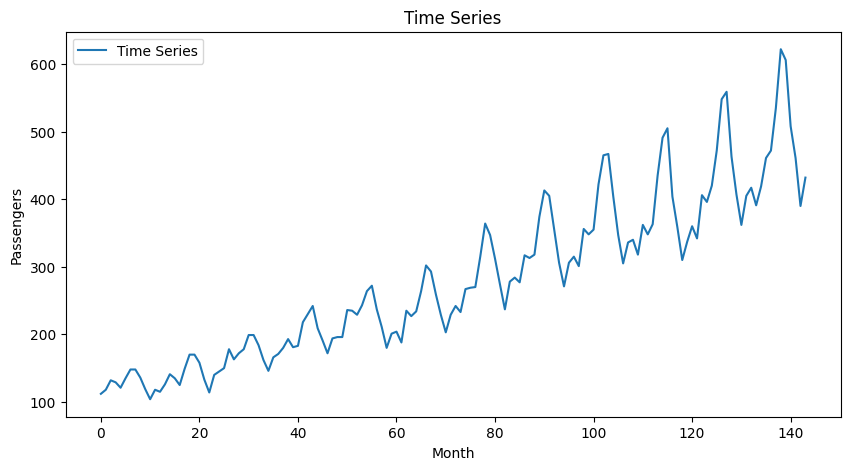

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(air_data.index, air_data['#Passengers'], label='Time Series')
plt.title('Time Series')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()

Trend: Upward trend in air travel

Seasonality: Peaks in travel during summer months

Irregular Patterns: Random fluctuations likely due to external factors

**Time Series Decomposition**

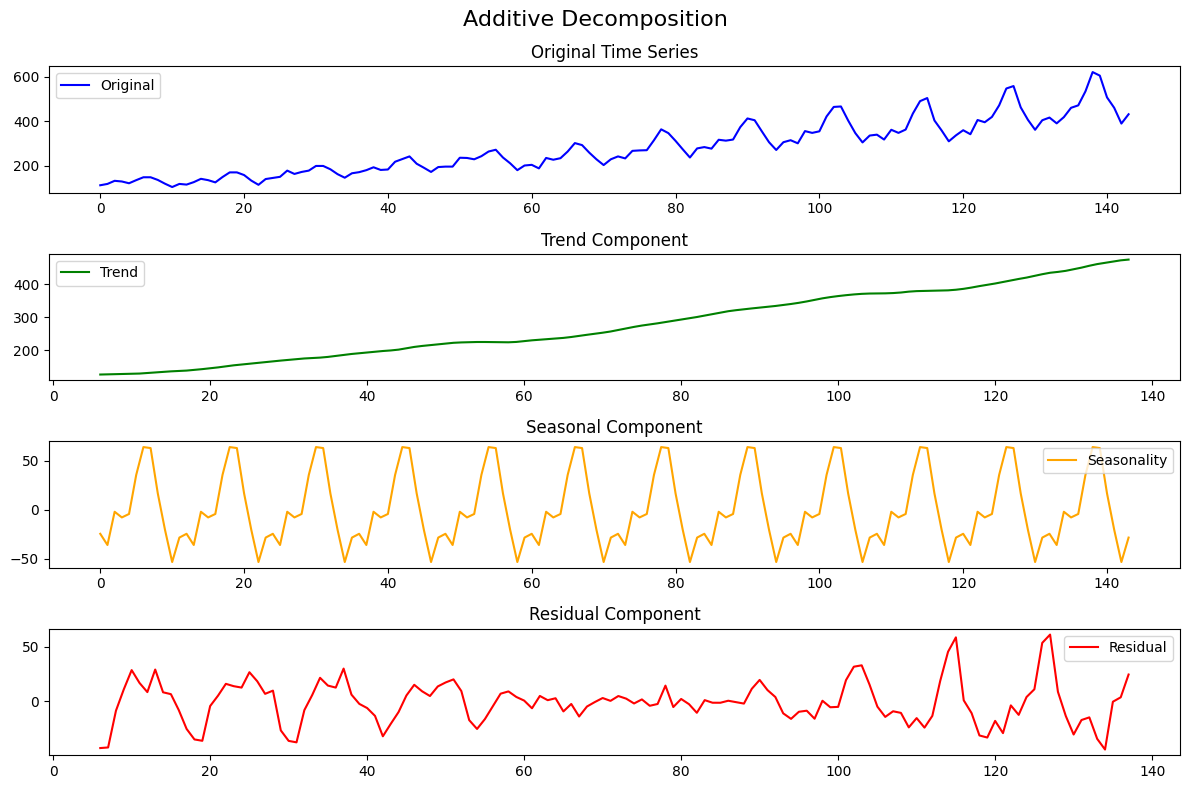

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive Decomposition
additive_decomposition = seasonal_decompose(air_data['#Passengers'], model='additive', period=12)

# Plot Additive Decomposition
plt.figure(figsize=(12, 8))
plt.suptitle('Additive Decomposition', fontsize=16)

plt.subplot(4, 1, 1)
plt.plot(air_data['#Passengers'], label='Original', color='blue')
plt.title('Original Time Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(additive_decomposition.trend, label='Trend', color='green')
plt.title('Trend Component')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(additive_decomposition.seasonal, label='Seasonality', color='orange')
plt.title('Seasonal Component')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(additive_decomposition.resid, label='Residual', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

Trend:A clear upward slope indicates a strong trend , indicating that air travel was becoming more popular.

Seasonality : appears to be fairly consistent over time, with a similar pattern repeating each year.The peaks likely correspond to summer months when air travel is more common.

Residual : appear to be relatively random, with no clear patterns or trends.

**Trend Estimation**

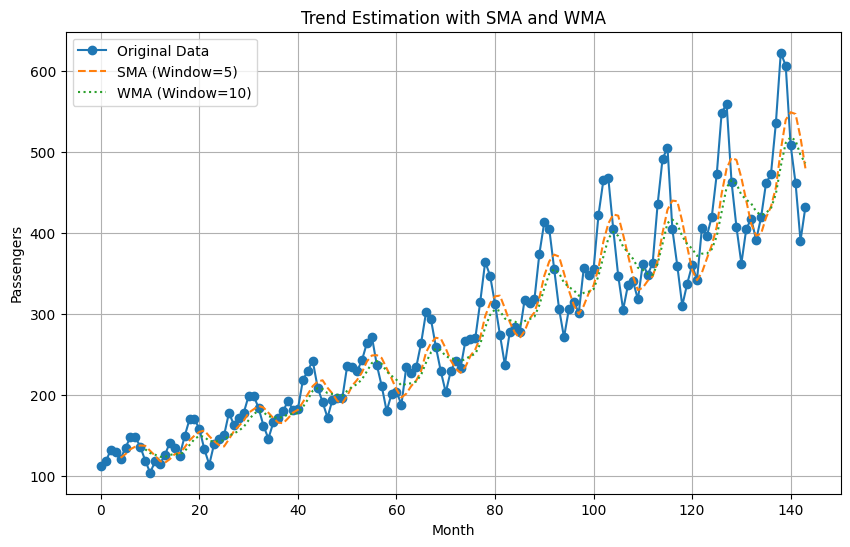

In [4]:
import numpy as np

# Simple Moving Average (SMA) function
def calculate_sma(data, window):
    return data.rolling(window=window).mean()

# Weighted Moving Average (WMA) function
def calculate_wma(data, window):
    weights = np.arange(1, window + 1)
    return data.rolling(window=window).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

# Parameters
window_size_sma = 5 # Adjust the window size as needed
window_size_wma = 10 # Adjust the window size as needed

# Calculate SMA and WMA
sma = calculate_sma(air_data['#Passengers'], window_size_sma)
wma = calculate_wma(air_data['#Passengers'], window_size_wma)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(air_data['#Passengers'], label="Original Data", marker="o")
plt.plot(sma, label=f"SMA (Window={window_size_sma})", linestyle="--")
plt.plot(wma, label=f"WMA (Window={window_size_wma})", linestyle=":")
plt.title("Trend Estimation with SMA and WMA")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()

**Exponential Smoothing**

<ipython-input-5-2cb31446fdd8>:12: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fitted_model = model.fit(smoothing_level=smoothing_level, smoothing_slope=smoothing_slope, optimized=False)


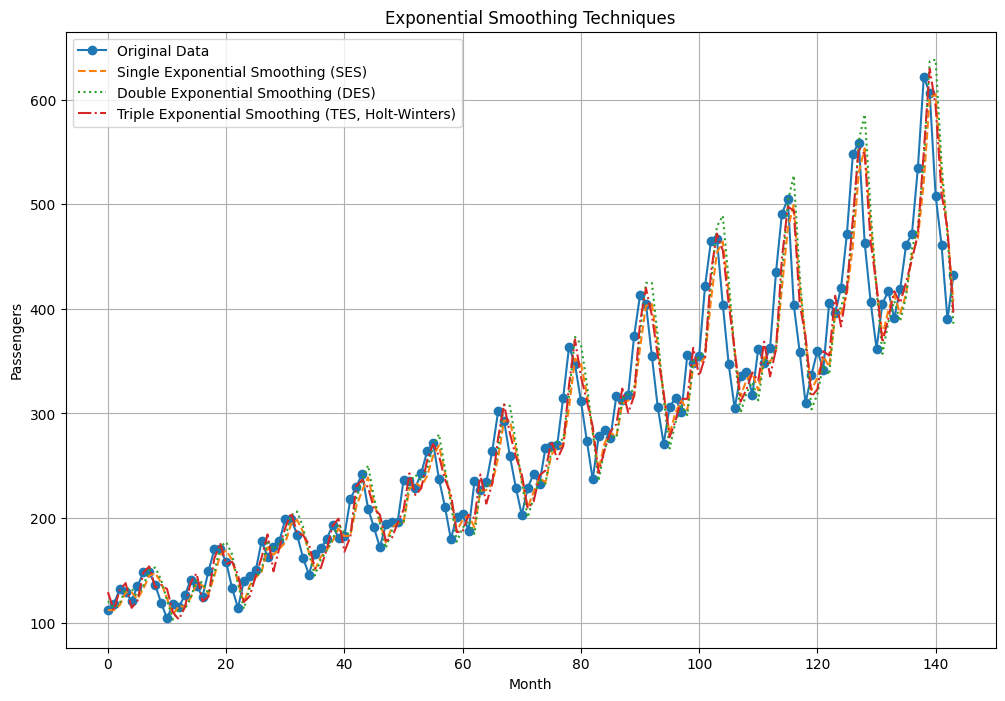

SES Forecast: 144    426.971494
145    426.971494
146    426.971494
dtype: float64
DES Forecast: 144    410.106229
145    397.450814
146    384.795399
dtype: float64
TES Forecast: 144    416.846564
145    417.092102
146    431.421947
dtype: float64


In [5]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# 1. Single Exponential Smoothing (SES)
def single_exponential_smoothing(data, smoothing_level=0.8):
    model = SimpleExpSmoothing(data)
    fitted_model = model.fit(smoothing_level=smoothing_level, optimized=False)
    return fitted_model.fittedvalues, fitted_model.forecast(steps=3)

# 2. Double Exponential Smoothing (DES)
def double_exponential_smoothing(data, trend="add", smoothing_level=0.8, smoothing_slope=0.2):
    model = ExponentialSmoothing(data, trend=trend, seasonal=None)
    fitted_model = model.fit(smoothing_level=smoothing_level, smoothing_slope=smoothing_slope, optimized=False)
    return fitted_model.fittedvalues, fitted_model.forecast(steps=3)

# 3. Triple Exponential Smoothing (Holt-Winters, TES)
def triple_exponential_smoothing(data, trend="add", seasonal="add", seasonal_periods=4):
    model = ExponentialSmoothing(data, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    fitted_model = model.fit(optimized=True)
    return fitted_model.fittedvalues, fitted_model.forecast(steps=3)

# Apply smoothing methods
smoothing_level = 0.8
smoothing_slope = 0.2
seasonal_periods = 4

ses_fitted, ses_forecast = single_exponential_smoothing(air_data['#Passengers'], smoothing_level)
des_fitted, des_forecast = double_exponential_smoothing(air_data['#Passengers'], "add", smoothing_level, smoothing_slope)
tes_fitted, tes_forecast = triple_exponential_smoothing(air_data['#Passengers'], "add", "add", seasonal_periods=seasonal_periods)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(air_data['#Passengers'], label="Original Data", marker="o")
plt.plot(ses_fitted, label="Single Exponential Smoothing (SES)", linestyle="--")
plt.plot(des_fitted, label="Double Exponential Smoothing (DES)", linestyle=":")
plt.plot(tes_fitted, label="Triple Exponential Smoothing (TES, Holt-Winters)", linestyle="-.")
plt.title("Exponential Smoothing Techniques")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()

# Forecast Output
print("SES Forecast:", ses_forecast)
print("DES Forecast:", des_forecast)
print("TES Forecast:", tes_forecast)